# 🏭 Feature Engineering en Datos Industriales
Dataset: `unclean_sensor_data.csv`

## Contexto industrial de dataset
El motor monitoreado impulsa un sistema hidráhulico que regula flujo, presión, temperatura y eficiencia operativa dentro de una planta petroquímica. La planta ha enfrentado paradas no programadas y cosots elevados de matenimiento correctivo. Se propone implementar monitoreo predictivo para anticipar fallas del motor y reducir downtime.

Los datos provienen de:

1. Sensores térmicos (RTD o termopares)
2. Acelerómetros industriales
3. Sensores de presión hidráulica
4. Medidores de flujo


## Objetivo de la practica
Diseñar y justificar nuevas variables (features) a partir de sensores industriales, que sean útiles para el monitoreo predicitivo.

Enfoque: Fase **Data Preparation** de CRISP-DM.


`Agrega el código necesario en los apartados que se indican y documenta el código propuesto, especificando la función pricipal del mismo. Toma como base el dataset limpio que se trabajo la practica pasada`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
 
sns.set_theme(style="whitegrid") # Estilo de los ejes de las tablas

pd.set_option("display.max_columns", None) # Muestra todas las columnas
pd.set_option("display.width", 140) # Configura el ancho en 140 caracteres

In [3]:
# Carga del dataset
df = pd.read_csv("datos_limpios.csv", sep=",", decimal=".")
df.head(10)

,Timestamp,Temperature (°C),Vibration (mm/s),Pressure (bar),Flow Rate (L/min),Efficiency (%)
0,2024-01-01 00:00:00,69.779570,0.896003,2.196334,447.485435,89.327750
1,2024-01-01 00:00:00,82.974601,3.110592,3.110580,222.490555,68.651984
2,2024-01-01 00:01:00,76.452902,6.376437,2.556589,363.421949,81.227055
3,2024-01-01 00:01:00,77.562998,1.057971,3.253704,206.671336,95.030315
4,2024-01-01 00:02:00,71.940435,0.434874,2.935875,447.829029,77.329880
5,2024-01-01 00:02:00,70.645506,0.905102,3.002867,312.517207,79.670811
6,2024-01-01 00:03:00,83.356770,0.587628,3.297378,391.160228,82.332951
7,2024-01-01 00:03:00,78.953362,1.064684,3.198188,144.353660,78.172967
8,2024-01-01 00:04:00,82.051562,3.344375,1.707913,397.435305,77.509114
9,2024-01-01 00:05:00,75.109908,8.537560,2.537794,438.185005,61.122444


# 🔹 Feature 1: Tasa de cambio
## Expresión matemática
ΔXₜ = Xₜ − Xₜ₋₁

## Justificación
Los cambios bruscos anticipan fallas más que valores absolutos.

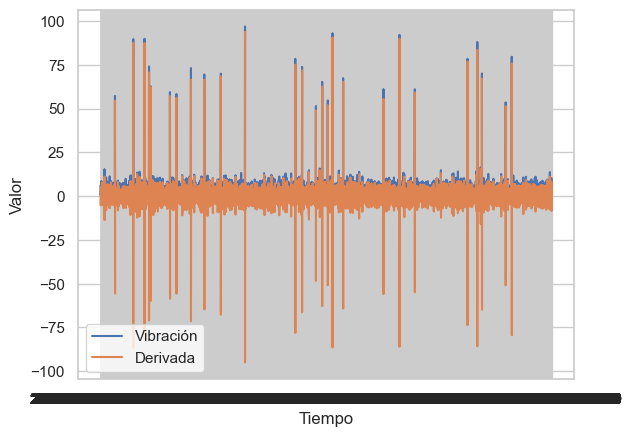

In [4]:
# Genera una nueva columna a partir de la derivada de la columna Vibration (mm/s), 
# apoyate de la función diff()
# Grafica la vibración respecto del tiempo así como la derivada y compara los resultados
df["Change Rate"] = df["Vibration (mm/s)"].diff()

plt.figure()

plt.plot(df["Timestamp"], df["Vibration (mm/s)"], label="Vibración")
plt.plot(df["Timestamp"], df["Change Rate"], label="Derivada")

plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

1. ¿Los picos de vibración coinciden con picos en la primera derivada?
2. ¿Existen cambios bruscos que no son evidentes en la señal original?
3. ¿Los cambios extremos son aislados o recurrentes?
4. ¿Podría esta variable anticipar una falla antes de que la vibración alcance niveles críticos?
5. ¿Es más informativo el nivel de vibración o su tasa de cambio?

# 🔹 Feature 2: Media móvil
## Expresión
μₜ = (1/n) Σ Xᵢ

## Justificación
Permite detectar tendencias reales eliminando ruido.

In [5]:
window = 60
df["Temperature (Roll Mean)"] = df["Temperature (°C)"].rolling(window).mean()
df[["Temperature (°C)", "Temperature (Roll Mean)"]].head(70)


,Temperature (°C),Temperature (Roll Mean)
0,69.779570,NaN
1,82.974601,NaN
2,76.452902,NaN
3,77.562998,NaN
4,71.940435,NaN
...,...,...
65,62.448889,75.668519
66,71.606479,75.472680
67,85.431321,75.580646
68,77.101549,75.498146


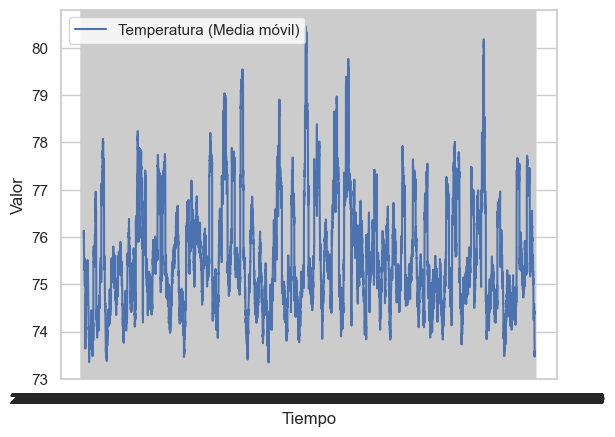

In [7]:
# Grafica la temperatura y la media móvil respecto del tiempo y compara
plt.figure()
 
plt.plot(df["Timestamp"], df["Temperature (Roll Mean)"], label="Temperatura (Media móvil)")

 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

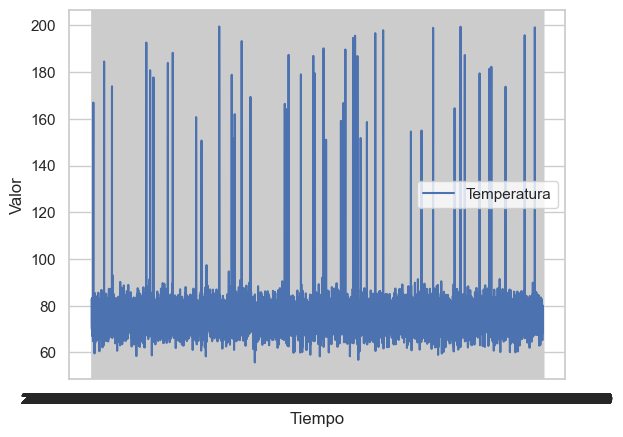

In [8]:
plt.figure()
 

plt.plot(df["Timestamp"], df["Temperature (°C)"], label="Temperatura")
 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

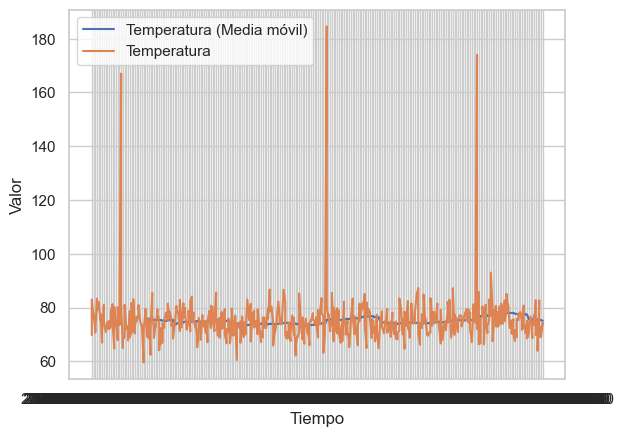

In [13]:
plt.figure()
 
plt.plot(df["Timestamp"].head(500), df["Temperature (Roll Mean)"].head(500), label="Temperatura (Media móvil)")
plt.plot(df["Timestamp"].head(500), df["Temperature (°C)"].head(500), label="Temperatura")
 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

1. ¿La media móvil revela tendencias que no se observan claramente en la señal original?
2. ¿La ventana de 60 muestras es adecuada o demasiado grande/pequeña?
3. ¿Cómo cambiaría la interpretación si modificamos el tamaño de ventana?

# 🔹 Feature 3: Desviación estándar móvil
## Expresión
σₜ = sqrt((1/n) Σ (Xᵢ − μ)²)

## Justificación
Detecta inestabilidad creciente previa a fallas.

In [ ]:
#Apoyate del código anterior, usa la misma ventana y genera una nueva característica con ventana móvil
#para la desviación estándar de las vibracionesy graficalo.
df["rollingstandarddeviation"] = df["Vibration (mm/s)"].rolling(window=60).std(ddof=0)

plt.figure()


plt.plot(df["Timestamp"], df["rollingstandarddeviation"], label="Desviación Estandar Movil")
 
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

1. ¿Existen periodos de alta volatilidad?
2. ¿La inestabilidad es progresiva o repentina?
3. ¿Se observan ciclos de estabilidad/inestabilidad?
4. ¿Podría la volatilidad ser mejor indicador de desgaste que la vibración absoluta?

# 🔹 Feature 4: Interacción física (Presión × Flujo)
## Expresión
Carga ≈ Presión × Flujo

## Justificación
Aproxima carga operativa del sistema.

In [ ]:
# En caso de que aun no se haya convertido el tipo para la columna Presure
for c in ["Pressure (bar)"]:
    df[c] = (df[c].astype(str)
                  .str.replace(",", ".", regex=False)   # coma decimal -> punto
                  .str.replace(r"[^0-9\.\-]", "", regex=True))  # quita texto/unidades
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [ ]:
# Calcula la carga hidráhulica y graficala

1. ¿Qué puede generar una carga elevada?
2. ¿La carga podría explicar cambios en vibración?
3. ¿Con qué otras variables en el dataset podemos relacionar la carga hifrahulica?

# 🔹 Feature 5: Health Index
## Expresión
HI = 0.3T + 0.4V + 0.3(100 − E)

## Justificación
Resume múltiples sensores en una métrica única para monitoreo.

In [ ]:
df["health_index"] = (
    0.3 * df["Temperature (°C)"] +
    0.4 * df["Vibration (mm/s)"] +
    0.3 * (100 - df["Efficiency (%)"])
)
df[["health_index"]].head()

# Agrega la grafica correspondiente

1. ¿Qué significan los valores constantes y cómo estos afectan los resultados?
2. ¿Cómo cambiaría el comportamiento si aumentamos el peso de vibración?


# Actividad Final
1) Diseña una nueva feature.
2) Escribe su fórmula matemática.
3) Justifica su uso.
4) Visualízala.


In [ ]:
df.to_csv("sensor_data_feature_engineered.csv", index=False)
print("Exportado correctamente")


In [15]:
df.dtypes

Timestamp                   object
Temperature (°C)           float64
Vibration (mm/s)           float64
Pressure (bar)             float64
Flow Rate (L/min)          float64
Efficiency (%)             float64
Change Rate                float64
Temperature (Roll Mean)    float64
dtype: object